In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../data/raw/ml-100k/u.data", sep="\t", names=["user_id", "item_id", "rating", "timestamp"])

In [4]:
df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
df.shape

(100000, 4)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


# EDA

In [8]:
n_users = df["user_id"].nunique()
n_items = df["item_id"].nunique()

print("Number of users:", n_users)
print("Number of items:", n_items)

Number of users: 943
Number of items: 1682


In [11]:
# Get interaction density

# This creates a matrix where rows = user_id, columns = each item, cell values = ratings by that user for that item
# If no rating, value = NaN
user_item_matrix = df.pivot(index="user_id", columns="item_id", values="rating")

In [14]:
# This is rows in df / total number of possible interactions
# So 1,000 users could interact with 1,000 items to give 1,000,000 interactions
# But in reality we only have number of rows as the actual interactions
# This makes our data sparse, hence we use collaborative filtering for better results
# Sparsity = 1 - density
sparsity = 1 - (df.shape[0] / (n_users * n_items))
print("Sparsity:", sparsity)

Sparsity: 0.9369533063577546


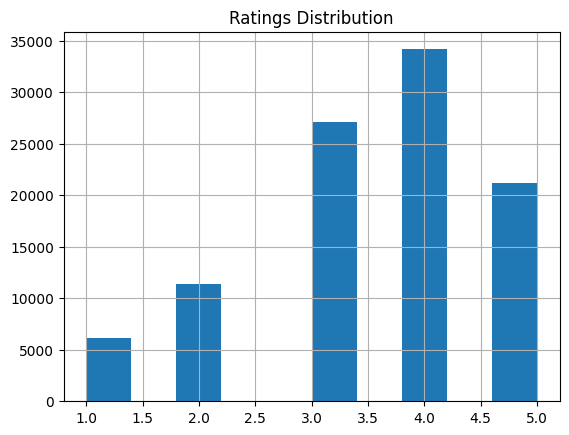

In [ ]:
df["rating"].hist()
plt.title("Ratings Distribution")
plt.show()

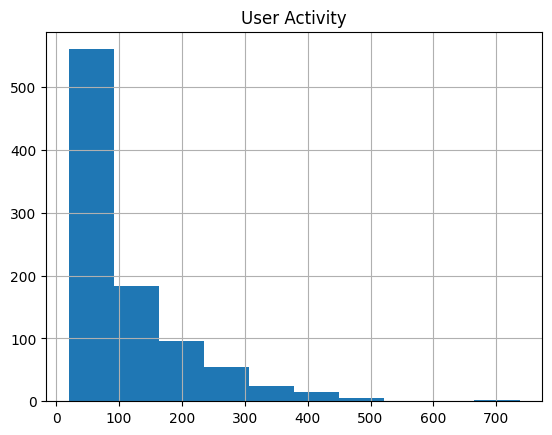

In [22]:
user_activity = df.groupby('user_id')['item_id'].count() # Number of items rated by each user

user_activity.hist()
plt.title("User Activity")
plt.show()

# X-axis: Number of items rated
# Y-axis: Number of users

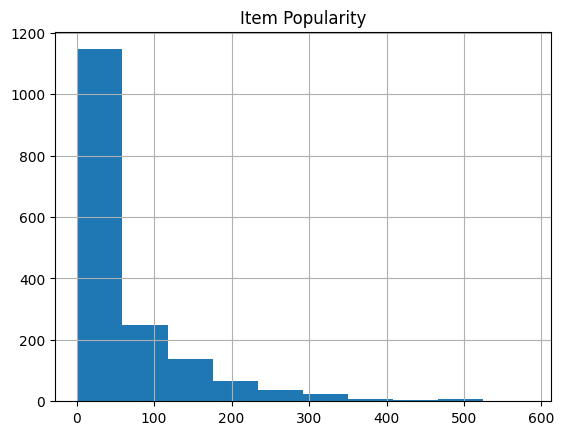

In [25]:
item_popularity = df.groupby("item_id")["user_id"].count()

item_popularity.hist()
plt.title("Item Popularity")
plt.show()

# X axis: Number of users per item
# Y axis: Number of items

# Data pre-processing

In [29]:
# Remove users with low-activity, less than 20 ratings
user_counts = df["user_id"].value_counts()

df = df[df["user_id"].isin(user_counts[user_counts >= 20].index)]

In [30]:
df.shape

(100000, 4)

In [31]:
# Remove low-popularity items
item_counts = df["item_id"].value_counts()

df = df[df["item_id"].isin(item_counts[item_counts >= 20].index)]

In [32]:
df.shape

(94968, 4)

In [33]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()

print(n_users, n_items)

943 939


In [ ]:
# Do train-test split such that each user is evenly split into both
# Simply doing train-test split like we usually do would result in some users only being in train and some only in test

train_list = []
test_list = []

for user in df["user_id"].unique():
    user_data = df[df["user_id"] == user]

    # if a user has less than two interactions, can't split
    if (len(user_data) < 2):
        continue
    
    train, test = train_test_split(user_data, test_size=0.2, random_state=42)

    train_list.append(train)
    test_list.append(test)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

In [35]:
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

In [36]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

# Baseline model

In [37]:
train_df.head()

,user_id,item_id,rating,timestamp
32721,196,287,3,881251884
17102,196,8,5,881251753
18853,196,1118,4,881252128
7842,196,663,5,881251911
17830,196,428,4,881251702


In [38]:
item_popularity = train_df.groupby('item_id')['user_id'].count()

In [39]:
item_popularity = item_popularity.sort_values(ascending=False)

In [40]:
top_n_items = item_popularity.head(10).index.tolist()
print(top_n_items)

[50, 258, 100, 181, 294, 286, 288, 121, 1, 127]


In [41]:
def recommend_popular(n=10):
    return item_popularity.head(n).index.tolist()

In [1]:
recommend_popular(5)

NameError: name 'recommend_popular' is not defined

## Better baseline model

In [44]:
# Don't recommmend movies user has already seen
def better_recommend_popular(user_id, train_df, n=10):
    seen_items = train_df[train_df["user_id"] == user_id]["item_id"]
    recommendations = [
        item for item in item_popularity.index
        if item not in seen_items.values
    ]

    return recommendations[:n]

In [47]:
better_recommend_popular(181, train_df, 5)

[50, 181, 127, 174, 56]

# Collaborative Filtering Model

In [5]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

In [6]:
train_df.head()

,user_id,item_id,rating,timestamp
0,196,287,3,881251884
1,196,8,5,881251753
2,196,1118,4,881252128
3,196,663,5,881251911
4,196,428,4,881251702


In [7]:
user_item_matrix = train_df.pivot(index="user_id", columns="item_id", values="rating")

In [8]:
user_item_matrix = user_item_matrix.fillna(0)

In [9]:
# Each item = vector of user ratings
# Compare items based on:
# Which users liked them
# How similarly they were rated
from sklearn.metrics.pairwise import cosine_similarity
item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

In [10]:
item_similarity_df[10]  # similarity of item 10 with others

item_id
1       0.213587
2       0.126255
3       0.133464
4       0.199368
5       0.037662
          ...   
1284    0.090532
1296    0.000000
1315    0.058923
1407    0.067516
1411    0.072017
Name: 10, Length: 939, dtype: float64

In [11]:
def get_similar_items(item_id, n=10):
    similar_items = item_similarity_df[item_id].sort_values(ascending=False)
    return similar_items.iloc[1:n+1].index.tolist()

In [12]:
def recommend_collab(user_id, train_df, n=10):
    user_items = train_df[train_df['user_id'] == user_id]['item_id']
    
    recommendations = []
    
    for item in user_items:
        similar_items = get_similar_items(item, n)
        recommendations.extend(similar_items)
    
    # Remove duplicates
    recommendations = list(set(recommendations))
    
    # Remove already seen items
    recommendations = [
        item for item in recommendations 
        if item not in user_items.values
    ]
    
    return recommendations[:n]

In [14]:
recommend_collab(196, train_df, 5)

[1, 514, 1028, 14, 15]

# Evaluation

In [18]:
# Precision@K & Recall@K
K = 10

In [15]:
def get_user_test_items(user_id, test_df):
    return test_df[test_df['user_id'] == user_id]['item_id'].values

In [16]:
def precision_recall_at_k(user_id, train_df, test_df, recommend_fn, K=10):
    
    recommended_items = recommend_fn(user_id, train_df, n=K)
    test_items = get_user_test_items(user_id, test_df)
    
    if len(test_items) == 0:
        return None, None
    
    # Convert to sets
    recommended_set = set(recommended_items)
    test_set = set(test_items)
    
    # Intersection
    relevant_items = recommended_set.intersection(test_set)
    
    precision = len(relevant_items) / K
    recall = len(relevant_items) / len(test_set)
    
    return precision, recall

In [19]:
precisions = []
recalls = []

for user in test_df['user_id'].unique():
    p, r = precision_recall_at_k(user, train_df, test_df, recommend_collab, K)
    
    if p is not None:
        precisions.append(p)
        recalls.append(r)

In [20]:
avg_precision = sum(precisions) / len(precisions)
avg_recall = sum(recalls) / len(recalls)

print("Precision@K:", avg_precision)
print("Recall@K:", avg_recall)

Precision@K: 0.09893955461293719
Recall@K: 0.061031667104882406
